# Exploratory Data Analysis — Online Course Enrollment Data

In this notebook we explore two datasets:
- **Course metadata** (307 courses, 16 genre columns)
- **User enrollment interactions** (233,306 rows, 33,901 unique users)

We generate a word cloud from course titles, analyze genre distributions, visualize enrollment patterns, and identify the top 20 most popular courses.

## 1. Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

## 2. Load Datasets

In [20]:
# Course genre/metadata dataset
course_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv')
print('Course dataset shape:', course_df.shape)
print('Columns:', course_df.columns.tolist())

Course dataset shape: (307, 16)
Columns: ['COURSE_ID', 'TITLE', 'Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision', 'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain']


In [21]:
# Ratings/enrollment dataset
ratings_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv')
print('Ratings dataset shape:', ratings_df.shape)
ratings_df.head()

Ratings dataset shape: (233306, 3)


,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


## 3. Word Cloud from Course Titles

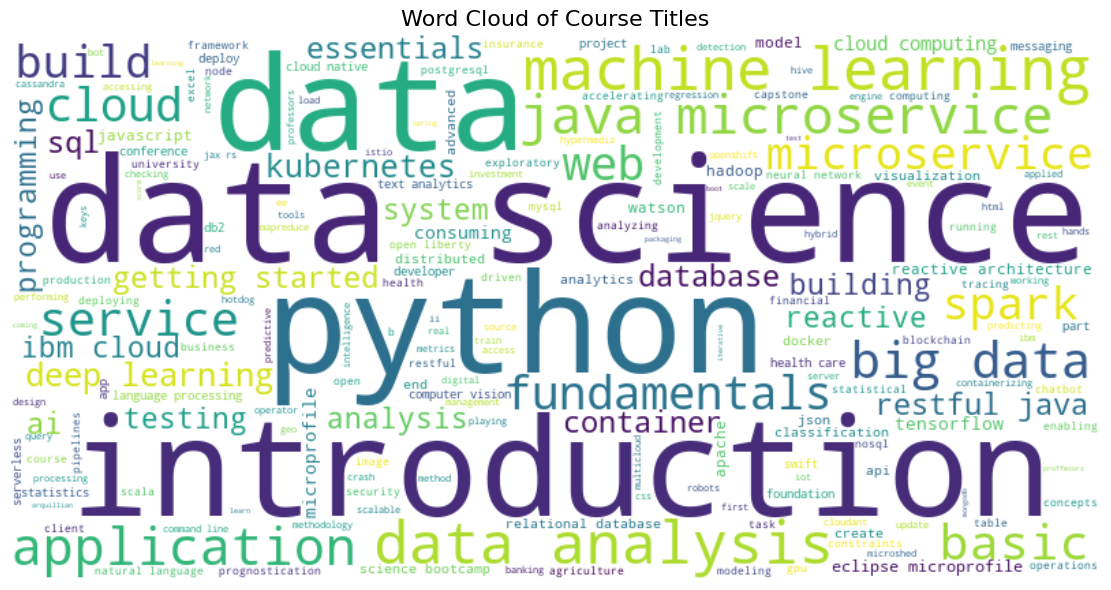

In [22]:
all_titles = ' '.join(course_df['TITLE'].values)

custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['using', 'with', 'for', 'and', 'the', 'to', 'in', 'of', 'a'])

wc = WordCloud(width=800, height=400, stopwords=custom_stopwords,
               background_color='white', colormap='viridis').generate(all_titles)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Course Titles', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Course Genre Distribution

In [23]:
genres = ['Database','Python','CloudComputing','DataAnalysis','Containers',
          'MachineLearning','ComputerVision','DataScience','BigData',
          'Chatbot','R','BackendDev','FrontendDev','Blockchain']

genre_counts = course_df[genres].sum().sort_values(ascending=False).reset_index()
genre_counts.columns = ['Genre', 'CourseCount']
print(genre_counts.to_string(index=False))

          Genre  CourseCount
     BackendDev           78
MachineLearning           69
       Database           60
   DataAnalysis           56
    DataScience           38
 CloudComputing           37
        BigData           36
         Python           28
    FrontendDev           19
     Containers           17
              R           17
 ComputerVision           10
        Chatbot            4
     Blockchain            4


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_15696\3201804453.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Genre', y='CourseCount', data=genre_counts, palette='Blues_d', ax=ax)
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_15696\3201804453.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


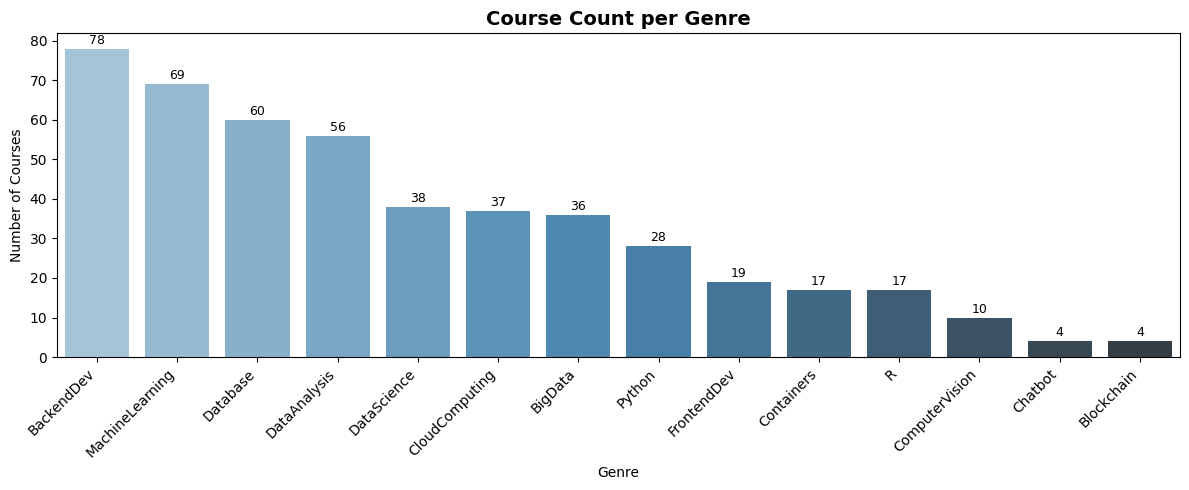

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x='Genre', y='CourseCount', data=genre_counts, palette='Blues_d', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Course Count per Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Courses')
for bar, val in zip(ax.patches, genre_counts['CourseCount']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** BackendDev (78) and MachineLearning (69) are the two most represented genres. Blockchain (8) is the least common, reflecting its niche status in the catalog.

## 5. Enrollment Distribution

In [25]:
user_counts = ratings_df.groupby('user').size().reset_index(name='enrollments')
print('Total unique users:', len(user_counts))
print(user_counts['enrollments'].describe().rename('Statistic').round(2))

Total unique users: 33901
count    33901.00
mean         6.88
std          5.82
min          1.00
25%          2.00
50%          6.00
75%          9.00
max         61.00
Name: Statistic, dtype: float64


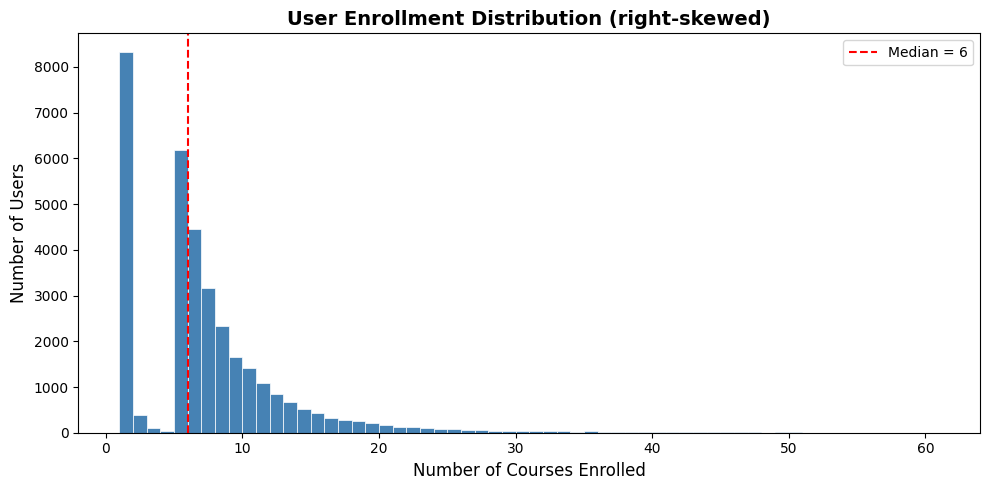

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(user_counts['enrollments'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of Courses Enrolled', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('User Enrollment Distribution (right-skewed)', fontsize=14, fontweight='bold')
ax.axvline(6, color='red', linestyle='--', label='Median = 6')
ax.legend()
plt.tight_layout()
plt.savefig('enrollment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The distribution is heavily right-skewed. Most users enrolled in just 1–6 courses (median = 6), but a small group of power users enrolled in up to 61 courses.

## 6. Top 20 Most Popular Courses

In [27]:
item_counts = ratings_df.groupby('item').size().reset_index(name='Ratings')
item_counts = item_counts.sort_values('Ratings', ascending=False).head(20)
top_courses = pd.merge(item_counts, course_df[['COURSE_ID','TITLE']], left_on='item', right_on='COURSE_ID')
top_courses = top_courses[['TITLE','Ratings']].reset_index(drop=True)
top_courses.index += 1
print(top_courses.to_string())
total_enroll = ratings_df.shape[0]
top20_pct = top_courses['Ratings'].sum() / total_enroll * 100
print(f'\nTop 20 courses account for {top20_pct:.1f}% of all enrollments')

                                           TITLE  Ratings
1                        python for data science    14936
2                   introduction to data science    14477
3                                   big data 101    13291
4                                     hadoop 101    10599
5                      data analysis with python     8303
6                       data science methodology     7719
7                   machine learning with python     7644
8                           spark fundamentals i     7551
9   data science hands on with open source tools     7199
10                         blockchain essentials     6719
11                data visualization with python     6709
12                             deep learning 101     6323
13                        build your own chatbot     5512
14                            r for data science     5237
15                                statistics 101     5015
16                         introduction to cloud     4983
17   docker es

**Insight:** The top 20 courses (led by *Python for Data Science* with 14,936 enrollments) account for 63.3% of all interactions, showing a strong popularity concentration effect.

## Summary

| Metric | Value |
|---|---|
| Total Courses | 307 |
| Total Users | 33,901 |
| Total Enrollments | 233,306 |
| Avg enrollments/user | 6.88 |
| Most popular genre | BackendDev (78 courses) |
| Top course | Python for Data Science (14,936 enrollments) |
| Top 20 coverage | 63.3% of all enrollments |